![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E10 - Pipeline LLM vs Agente IA
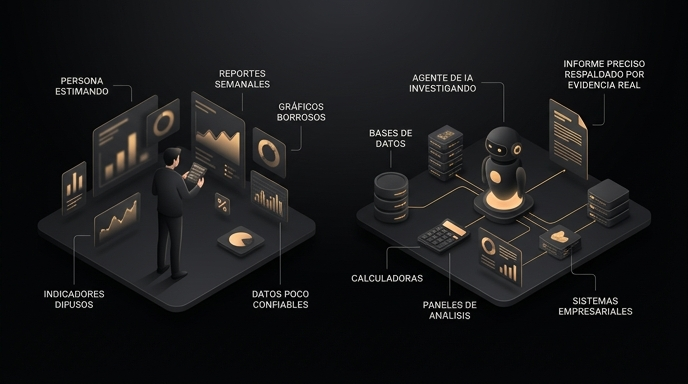

## Escenario

Tu empresa necesita automatizar un **reporte semanal de ventas**.

En este notebook vas a comparar dos formas de resolver la misma consulta:

1. Un **pipeline LLM tradicional**, que responde texto sin consultar datos.
2. Un **agente IA**, que usa herramientas, observa datos y responde con evidencia.

Todo el contenido esta en castellano para que puedas concentrarte en el problema y en el codigo.


## Conceptos

Un **pipeline LLM** es como pedirle a alguien que responda con lo que recuerda. Puede sonar convincente, pero no necesariamente consulto datos reales.

Un **agente IA** es mas parecido a un analista: antes de responder, consulta datos, calcula y despues arma una respuesta.

```text
Pipeline LLM: consulta -> texto generado
Agente IA: consulta -> herramienta -> observacion -> herramienta -> observacion -> respuesta final
```

La diferencia importante no es el largo del texto. La diferencia es si el sistema actua y observa antes de responder.


## Datos de trabajo


In [ ]:
DATOS_VENTAS = [
    {"semana": "2026-W22", "producto": "Pro", "unidades": 12, "precio_unitario": 30},
    {"semana": "2026-W22", "producto": "Starter", "unidades": 20, "precio_unitario": 12},
    {"semana": "2026-W22", "producto": "Enterprise", "unidades": 3, "precio_unitario": 120},
]

CONSULTA = "Genera el reporte semanal de ventas para 2026-W22"


## Pipeline tradicional


In [ ]:
def pipeline_llm(consulta: str) -> str:
    """Pipeline simulado: devuelve una respuesta inventada sin usar datos."""
    return (
        "Las ventas parecen fuertes esta semana. "
        "La empresa probablemente vendio alrededor de 1.000 USD "
        "y Pro parece ser el producto principal."
    )


respuesta_pipeline = pipeline_llm(CONSULTA)
print(f"pipeline_llm(CONSULTA) -> {respuesta_pipeline}")


## Herramientas mockeadas


In [ ]:
def buscar_datos_ventas(semana: str) -> list[dict]:
    """Herramienta: busca filas de ventas para una semana."""
    return [fila for fila in DATOS_VENTAS if fila["semana"] == semana]


def calcular_total(filas: list[dict]) -> float:
    """Herramienta: calcula el ingreso total."""
    return sum(fila["unidades"] * fila["precio_unitario"] for fila in filas)


## Solucion - Pipeline tipo agente


In [ ]:
def pipeline_agente(consulta: str) -> str:
    """Flujo tipo agente: usa herramientas antes de responder."""
    semana = "2026-W22"

    print("[Accion] buscar_datos_ventas")
    filas = buscar_datos_ventas(semana)
    print(f"[Observacion] filas -> {filas}")

    print("[Accion] calcular_total")
    total = calcular_total(filas)
    print(f"[Observacion] total -> {total}")

    return f"Reporte semanal para {semana}: {len(filas)} filas de ventas, ingreso total USD {total}."


respuesta_agente = pipeline_agente(CONSULTA)
print(f"pipeline_agente(CONSULTA) -> {respuesta_agente}")


## Reflexion final

Ejecutaste la misma consulta con dos enfoques.

Preguntas:

1. ¿Cuál respuesta esta basada en datos?
2. ¿Qué pasaría si `buscar_datos_ventas()` devuelve una lista vacia?
3. ¿Qué haría el pipeline tradicional?
4. ¿Qué podría hacer el agente?

Idea esperada:

- El pipeline probablemente seguiria escribiendo algo convincente.
- El agente podria observar `[]` y responder: "No hay datos para esa semana".
